In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib
import yfinance as yf

B. Load Historical Stock Data

In [5]:
df = yf.download("TSLA", start="2020-01-01", end="2025-01-01")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


C. Data Preparation
Check Data Types

In [6]:
print(df.dtypes)

Price   Ticker
Close   TSLA      float64
High    TSLA      float64
Low     TSLA      float64
Open    TSLA      float64
Volume  TSLA        int64
dtype: object


Ensure Correct Types

In [7]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

df[numeric_cols] = df[numeric_cols].astype(float)

Check Missing Values

In [8]:
df.isnull().sum()

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

Handle Missing Values

In [9]:
df = df.dropna()

D. Compute Technical Indicators
1. Simple Moving Average (SMA)

In [12]:
print(df.columns)

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])


In [13]:
df.columns = df.columns.get_level_values(0)

In [14]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

2. Exponential Moving Average (EMA)

In [15]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
df['EMA_50'] = talib.EMA(df['Close'], timeperiod=50)

3. Relative Strength Index (RSI)

In [16]:
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

Interpretation:

RSI > 70 → Overbought
RSI < 30 → Oversold

4. MACD

In [17]:
macd, macd_signal, macd_hist = talib.MACD(
    df['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

df['MACD'] = macd
df['MACD_Signal'] = macd_signal
df['MACD_Hist'] = macd_hist

E. Apply PyNance Metrics

In [18]:
returns = df['Close'].pct_change()

print("Average Daily Return:", returns.mean())
print("Volatility:", returns.std())

Average Daily Return: 0.0029974098063984965
Volatility: 0.042320384974952906


F. Visualizations

1. Closing Price with Moving Averages

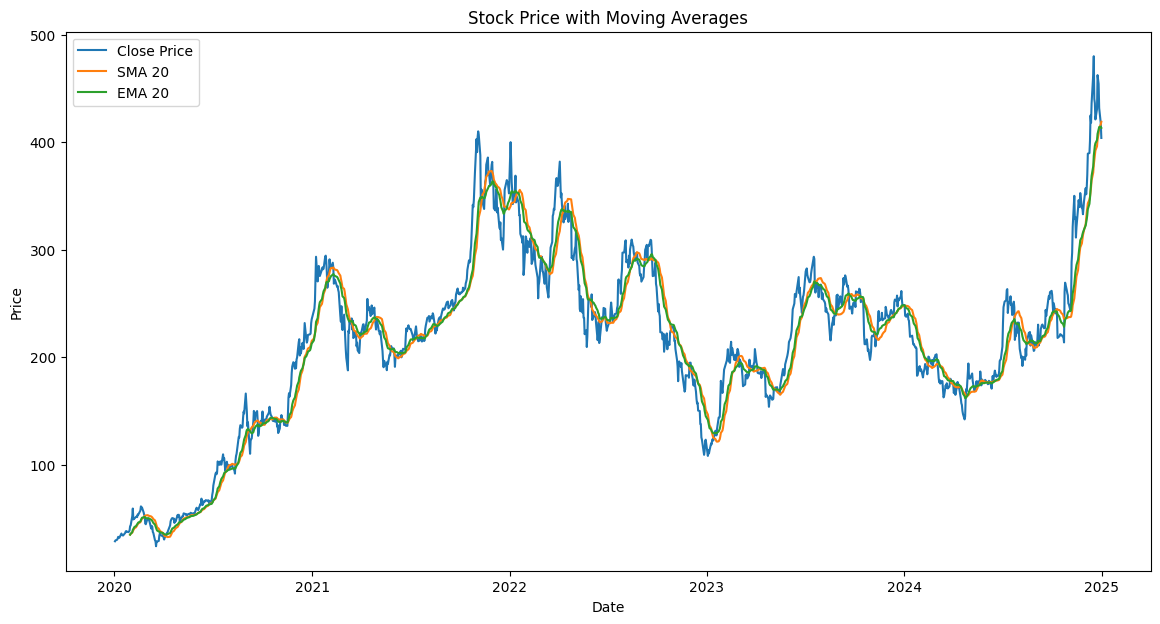

In [19]:
plt.figure(figsize=(14,7))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['EMA_20'], label='EMA 20')

plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

2. RSI Plot

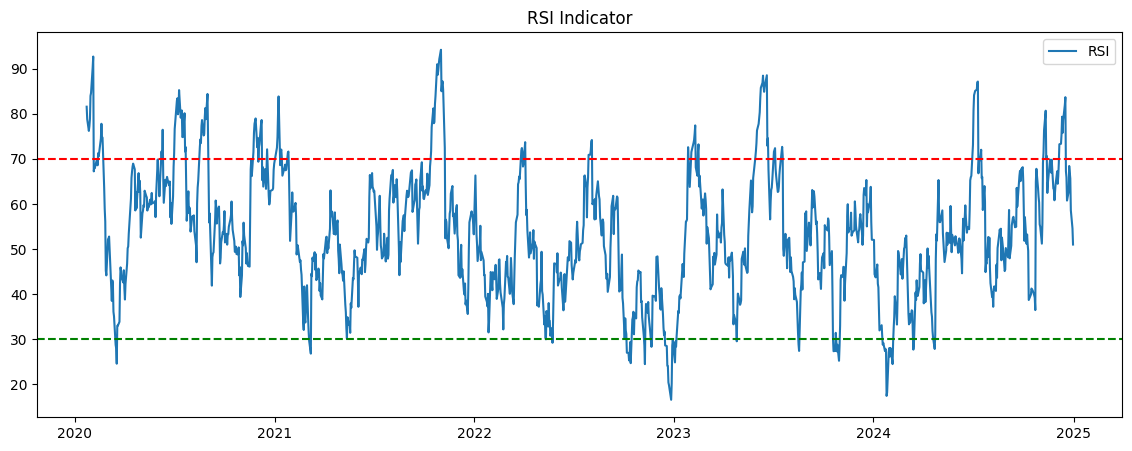

In [20]:
plt.figure(figsize=(14,5))

plt.plot(df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title('RSI Indicator')
plt.legend()

plt.show()

3. MACD Plot

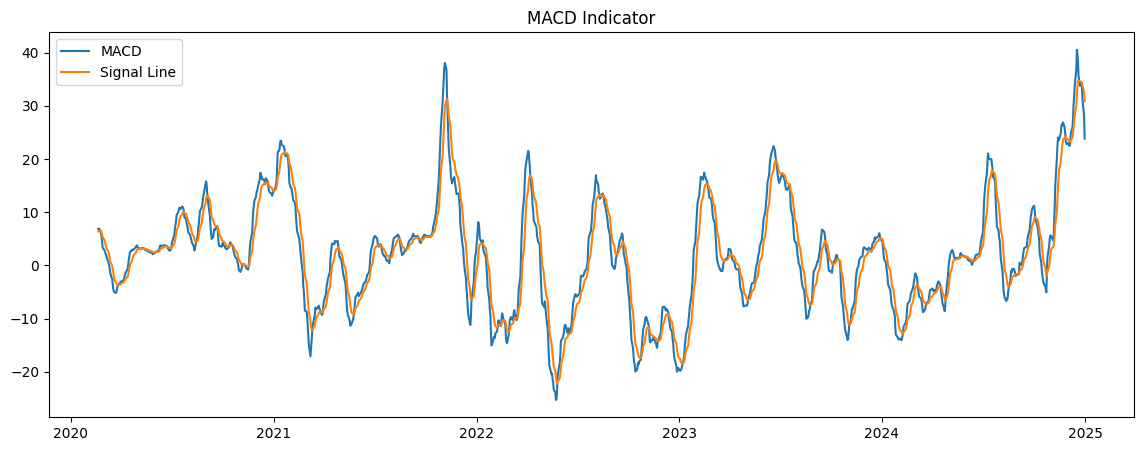

In [21]:
plt.figure(figsize=(14,5))

plt.plot(df['MACD'], label='MACD')
plt.plot(df['MACD_Signal'], label='Signal Line')

plt.title('MACD Indicator')
plt.legend()

plt.show()

G. Summary Section (VERY IMPORTANT)

Summary of Data Preparation and Analysis
Loaded historical stock price data using Yahoo Finance
Verified numerical columns and corrected data types
Checked and handled missing values using forward fill/dropna
Computed technical indicators:
SMA
EMA
RSI
MACD
Generated visualizations to analyze market trends and momentum
Observed periods of overbought and oversold market conditions using RSI
MACD analysis helped identify momentum shifts and possible trend reversals